# License Plate Detection System

**Tier:** Tier 1 – CORE Project  
**Task:** Object Detection  
**Model:** YOLO  

## Project Goal
The goal of this project is to detect license plates in vehicle images using a YOLO object detection model. The system will identify the location of a license plate and display a bounding box around it.

## Step 1: Dataset Setup

The License Plate Dataset was obtained from Kaggle and uploaded to Google Drive. The dataset is extracted in Google Colab so that the images and labels can be used for the project.

In [30]:
!unzip -q "/content/drive/MyDrive/license_plate_dataset.zip" -d "/content/license_plate_dataset"
print("Dataset extracted successfully!")

replace /content/license_plate_dataset/archive/classes.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset extracted successfully!


## Step 2: Verify the Dataset Structure

Before training the model, the dataset structure is checked to confirm that the required files and folders were extracted correctly.

In [31]:
import os

dataset_path = "/content/license_plate_dataset"

print("Files and folders in the dataset:")
print(os.listdir(dataset_path))

Files and folders in the dataset:
['archive']


### Check the Archive Folder

The extracted dataset contains an archive folder. The contents of this folder are checked to locate the images, labels, and configuration files.

In [32]:
archive_path = "/content/license_plate_dataset/archive"

print("Files and folders inside archive:")
print(os.listdir(archive_path))

Files and folders inside archive:
['dataset.yaml', 'classes.txt', 'labels', 'images', 'data.yaml']


## Step 3: Check Images and Labels

The dataset contains separate folders for images and labels. In this step, the contents of these folders are checked to confirm that the training and validation data are organized correctly.

In [33]:
images_path = "/content/license_plate_dataset/archive/images"
labels_path = "/content/license_plate_dataset/archive/labels"

print("Image folders:", os.listdir(images_path))
print("Label folders:", os.listdir(labels_path))

Image folders: ['train', 'val']
Label folders: ['train.cache', 'val.cache', 'train', 'val']


## Step 4: Count Training and Validation Files

The number of training and validation images and their corresponding label files are counted to verify that the dataset is complete and properly organized.

In [34]:
train_images = os.listdir(images_path + "/train")
val_images = os.listdir(images_path + "/val")

train_labels = os.listdir(labels_path + "/train")
val_labels = os.listdir(labels_path + "/val")

print("Training images:", len(train_images))
print("Training labels:", len(train_labels))
print("Validation images:", len(val_images))
print("Validation labels:", len(val_labels))
print("Total images:", len(train_images) + len(val_images))

Training images: 1526
Training labels: 1526
Validation images: 169
Validation labels: 169
Total images: 1695


## Step 5: Check the Dataset Configuration

The dataset configuration file is reviewed to verify the training and validation paths and the class information required by the YOLO model.

In [35]:
yaml_path = "/content/license_plate_dataset/archive/dataset.yaml"

with open(yaml_path, "r") as file:
    print(file.read())

train: /kaggle/input/license-plate-dataset/archive/images/train
val: /kaggle/input/license-plate-dataset/archive/images/val

nc: 1,  # Number of classes
names: {0: 'license_plate'}


## Step 6: Create a Colab-Compatible Dataset Configuration

The original dataset configuration uses Kaggle file paths. Since this project is being developed in Google Colab, a new configuration file is created with paths that match the dataset location in the Colab environment. The dataset contains one class: license_plate.

In [36]:
colab_yaml = """
train: /content/license_plate_dataset/archive/images/train
val: /content/license_plate_dataset/archive/images/val

nc: 1
names:
  0: license_plate
"""

new_yaml_path = "/content/license_plate_dataset/archive/data.yaml"

with open(new_yaml_path, "w") as file:
    file.write(colab_yaml)

print("Colab data.yaml created successfully!")
print()
print(open(new_yaml_path).read())

Colab data.yaml created successfully!


train: /content/license_plate_dataset/archive/images/train
val: /content/license_plate_dataset/archive/images/val

nc: 1
names:
  0: license_plate



## Step 7: Inspect Sample Images

A few training images are displayed to visually inspect the dataset before model training. This helps confirm that the images contain vehicles and visible license plates and that the dataset is appropriate for the project.

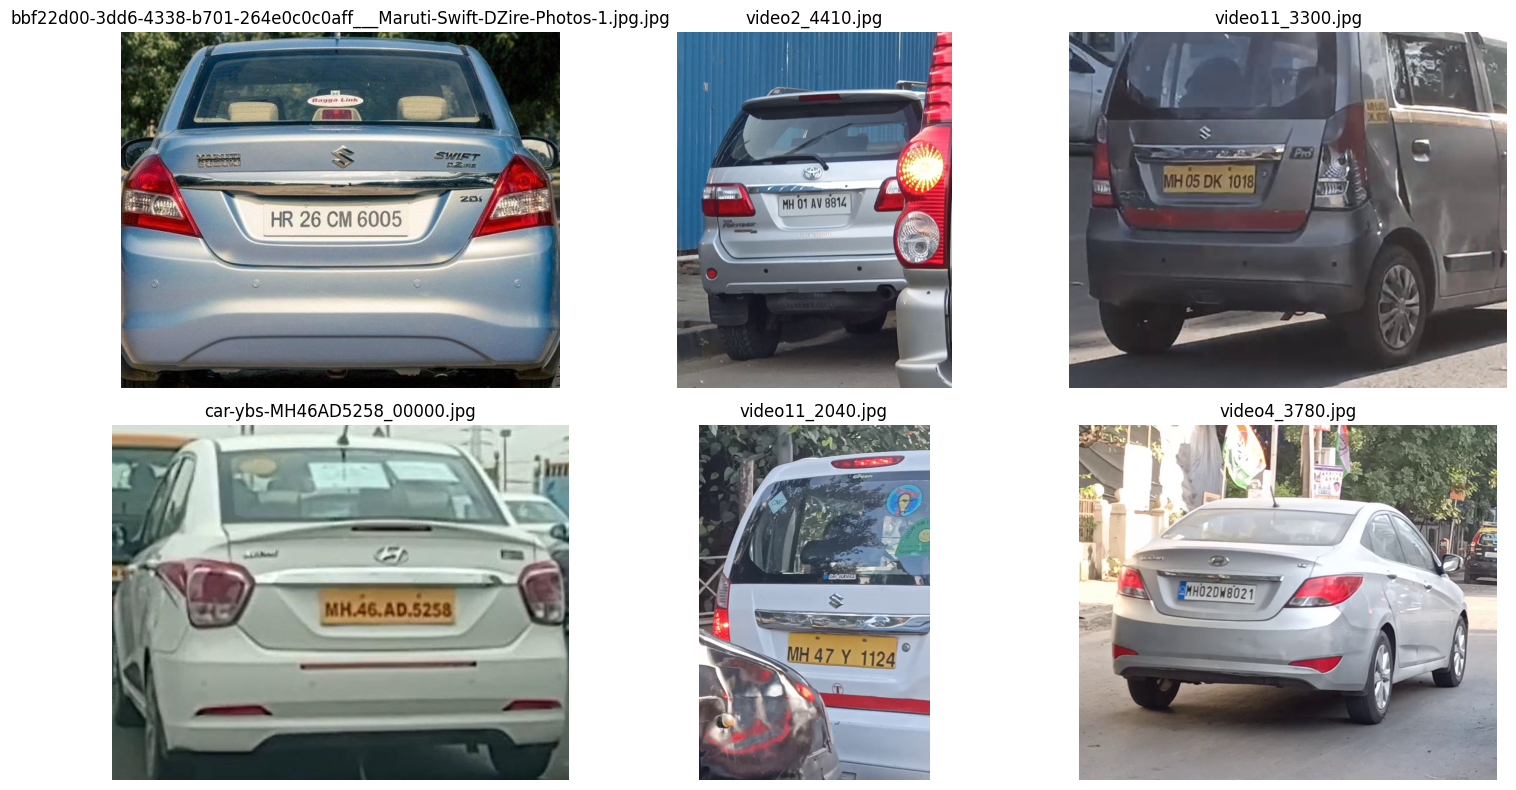

In [37]:
import matplotlib.pyplot as plt
from PIL import Image
import os

train_image_path = "/content/license_plate_dataset/archive/images/train"

sample_images = os.listdir(train_image_path)[:6]

plt.figure(figsize=(15, 8))

for i, image_name in enumerate(sample_images):
    image = Image.open(os.path.join(train_image_path, image_name))

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 8: Verify License Plate Annotations

The YOLO annotations are visualized on sample training images to verify that the bounding boxes correctly identify the license plate locations. This check helps confirm that the labeled data is suitable for training the object detection model.

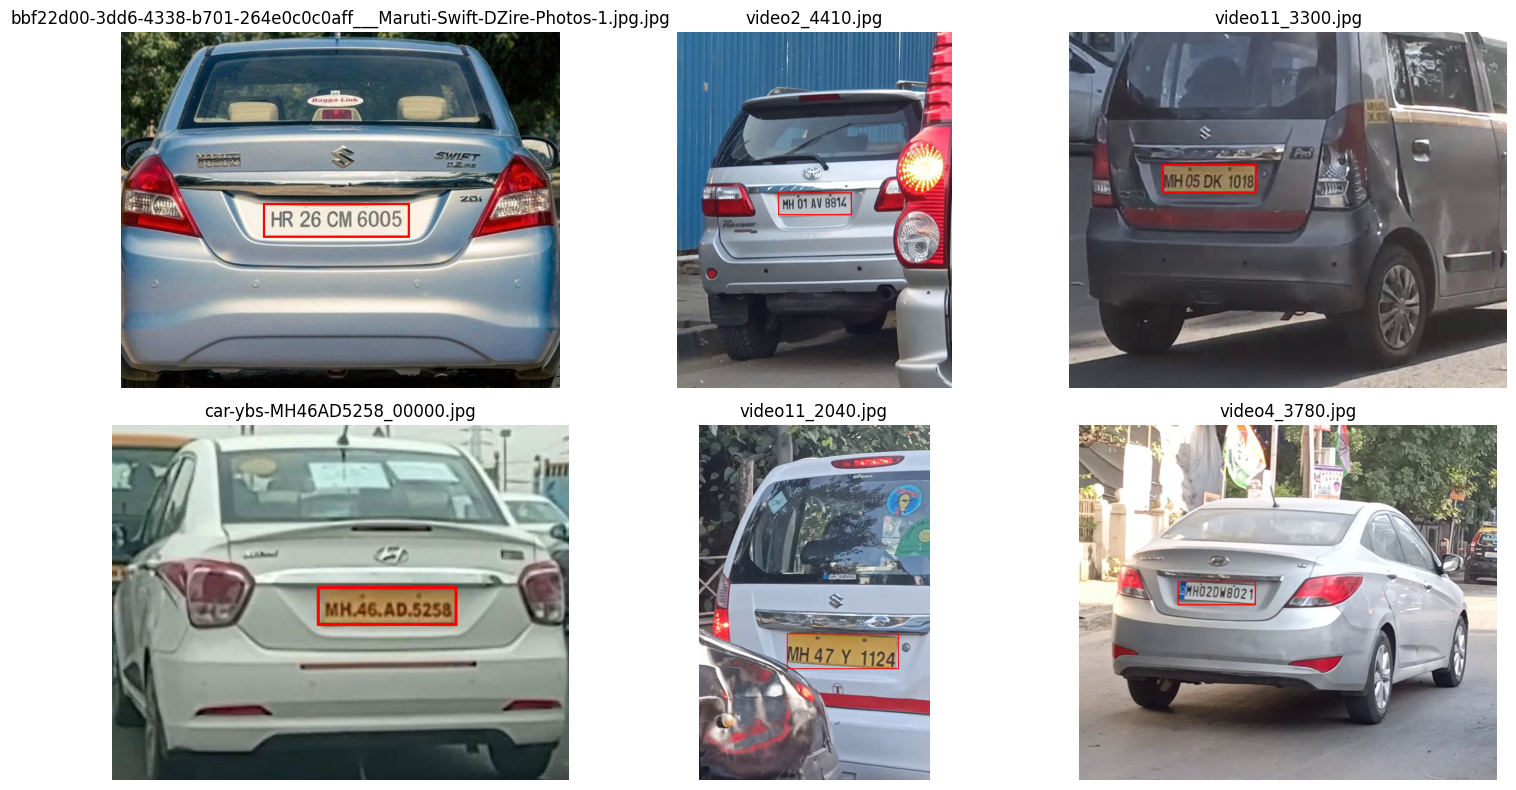

In [38]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import os

train_images_path = "/content/license_plate_dataset/archive/images/train"
train_labels_path = "/content/license_plate_dataset/archive/labels/train"

sample_images = os.listdir(train_images_path)[:6]

plt.figure(figsize=(15, 8))

for i, image_name in enumerate(sample_images):
    image_path = os.path.join(train_images_path, image_name)
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    width, height = image.size

    label_name = os.path.splitext(image_name)[0] + ".txt"
    label_path = os.path.join(train_labels_path, label_name)

    if os.path.exists(label_path):
        with open(label_path, "r") as file:
            for line in file:
                values = line.strip().split()

                class_id = int(values[0])
                x_center, y_center, box_width, box_height = map(float, values[1:5])

                x1 = (x_center - box_width / 2) * width
                y1 = (y_center - box_height / 2) * height
                x2 = (x_center + box_width / 2) * width
                y2 = (y_center + box_height / 2) * height

                draw.rectangle([x1, y1, x2, y2], outline="red", width=3)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 9: Check GPU Availability

Google Colab is used as the development environment for this project. GPU availability is checked before running the YOLO model because GPU acceleration can improve the speed of computer vision tasks.

In [39]:
!nvidia-smi

Sat Sep 26 03:20:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             31W /   70W |    1375MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 10: Verify Dataset After GPU Setup

After enabling the T4 GPU, the dataset location is checked again to confirm that the required training files are still available in the Colab environment.

In [40]:
import os

dataset_path = "/content/license_plate_dataset/archive"

if os.path.exists(dataset_path):
    print("Dataset is available.")
    print("Dataset contents:", os.listdir(dataset_path))
else:
    print("Dataset needs to be extracted again.")

Dataset is available.
Dataset contents: ['dataset.yaml', 'classes.txt', 'labels', 'images', 'data.yaml']


### Reconnect Google Drive

Google Drive is reconnected after the Colab runtime restart so the license plate dataset can be accessed again.

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Restore Dataset After Runtime Restart

The Colab runtime restart cleared the temporary dataset files. The dataset is extracted again from the ZIP file stored in Google Drive.

In [42]:
import os

zip_path = "/content/drive/MyDrive/license_plate_dataset.zip"
extract_path = "/content/license_plate_dataset"

!unzip -q "$zip_path" -d "$extract_path"

print("Dataset restored successfully!")
print("Dataset contents:", os.listdir(extract_path))

replace /content/license_plate_dataset/archive/classes.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset restored successfully!
Dataset contents: ['archive']


## Step 11: Restore the YOLO Dataset Configuration

The Colab-compatible YOLO configuration file is recreated after the runtime restart. It defines the training and validation image locations and the license plate class used by the model.

In [43]:
colab_yaml = """
train: /content/license_plate_dataset/archive/images/train
val: /content/license_plate_dataset/archive/images/val

nc: 1
names:
  0: license_plate
"""

yaml_path = "/content/license_plate_dataset/archive/data.yaml"

with open(yaml_path, "w") as file:
    file.write(colab_yaml)

print("YOLO data.yaml restored successfully!")
print()
print(open(yaml_path).read())

YOLO data.yaml restored successfully!


train: /content/license_plate_dataset/archive/images/train
val: /content/license_plate_dataset/archive/images/val

nc: 1
names:
  0: license_plate



## Step 12: Install Ultralytics YOLO

Ultralytics YOLO is installed to provide the object detection framework used for the License Plate Detection project. The pretrained YOLO model will first be tested before training it on the project dataset.

In [44]:
!pip install -q ultralytics

from ultralytics import YOLO

print("Ultralytics YOLO installed successfully!")

Ultralytics YOLO installed successfully!


## Step 13: First Working Demo with Pretrained YOLO

A pretrained YOLO model is tested on a sample image to verify that the object detection pipeline works correctly in Google Colab before training the model on the license plate dataset.


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 6.2ms
Speed: 2.0ms preprocess, 6.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


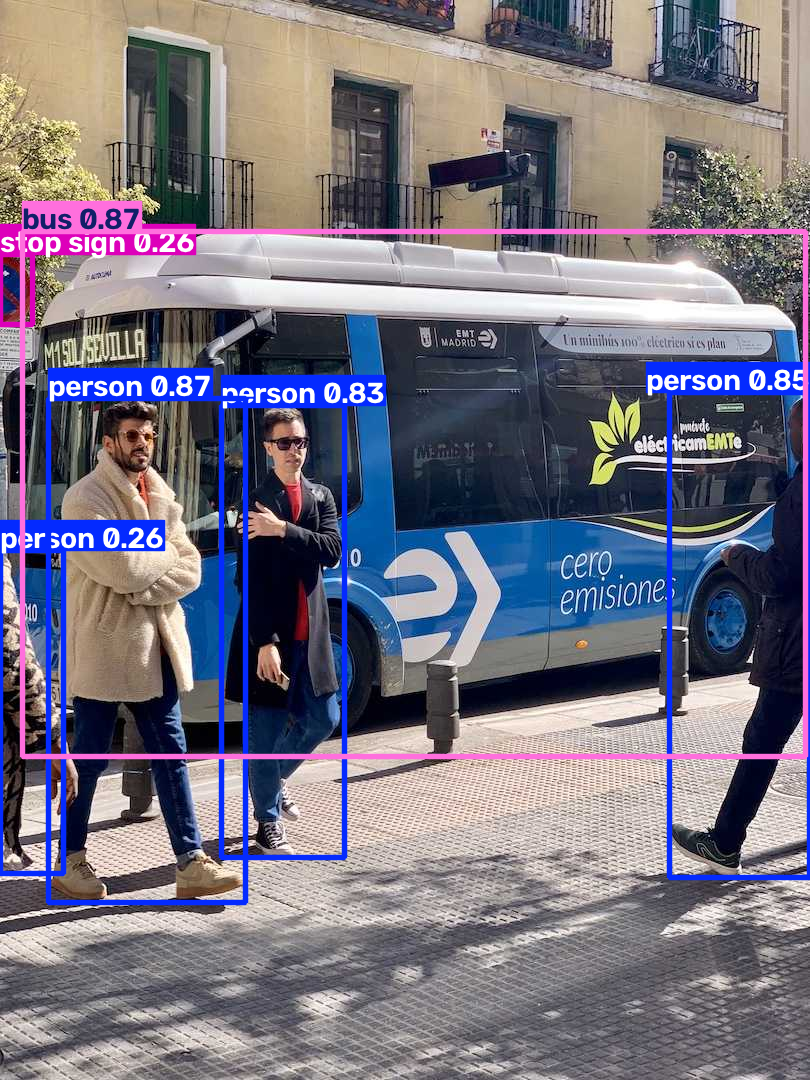

Pretrained YOLO model is working successfully!


In [45]:
from ultralytics import YOLO

# Load a pretrained YOLO model
model = YOLO("yolov8n.pt")

# Run object detection on the sample image
results = model("https://ultralytics.com/images/bus.jpg")

# Display the detection result
results[0].show()

print("Pretrained YOLO model is working successfully!")

## Step 14: Test the Pretrained Model on Project Data

The pretrained YOLO model is tested on a sample image from the license plate dataset before custom training. This provides a baseline and helps show why project-specific training is needed for license plate detection.

Testing image: bbf22d00-3dd6-4338-b701-264e0c0c0aff___Maruti-Swift-DZire-Photos-1.jpg.jpg

image 1/1 /content/license_plate_dataset/archive/images/train/bbf22d00-3dd6-4338-b701-264e0c0c0aff___Maruti-Swift-DZire-Photos-1.jpg.jpg: 544x640 1 car, 1 truck, 11.1ms
Speed: 2.5ms preprocess, 11.1ms inference, 4.0ms postprocess per image at shape (1, 3, 544, 640)


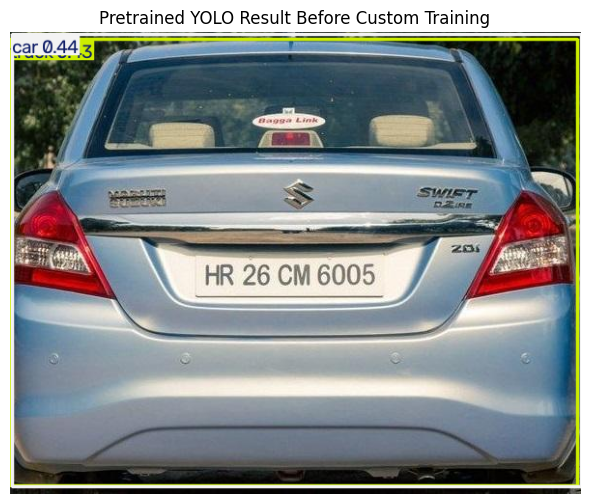

In [46]:
import os
from PIL import Image
import matplotlib.pyplot as plt

train_images_path = "/content/license_plate_dataset/archive/images/train"

# Select one sample image from the training dataset
sample_image_name = os.listdir(train_images_path)[0]
sample_image_path = os.path.join(train_images_path, sample_image_name)

print("Testing image:", sample_image_name)

# Run the pretrained YOLO model
results = model(sample_image_path)

# Display the result
annotated_image = results[0].plot()

plt.figure(figsize=(10, 6))
plt.imshow(annotated_image[:, :, ::-1])
plt.axis("off")
plt.title("Pretrained YOLO Result Before Custom Training")
plt.show()

## Step 15: Train the License Plate Detection Model

The pretrained YOLO model is fine-tuned on the license plate dataset so that it can learn to detect the project-specific license_plate class. The T4 GPU is used to accelerate model training.

In [49]:
from ultralytics import YOLO

# Start with a pretrained lightweight YOLO model
model = YOLO("yolov8n.pt")

# Train on the license plate dataset
results = model.train(
    data="/content/license_plate_dataset/archive/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/license_plate_project",
    name="license_plate_model"
)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/license_plate_dataset/archive/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=license_plate_model-4, nbs=

## Step 16: Test the Trained License Plate Model

The best trained YOLO model is tested on a validation image that was not used for model training. This helps evaluate whether the model can correctly detect license plates on unseen data.

Testing validation image: video6_650.jpg

image 1/1 /content/license_plate_dataset/archive/images/val/video6_650.jpg: 640x544 1 license_plate, 7.1ms
Speed: 1.8ms preprocess, 7.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 544)


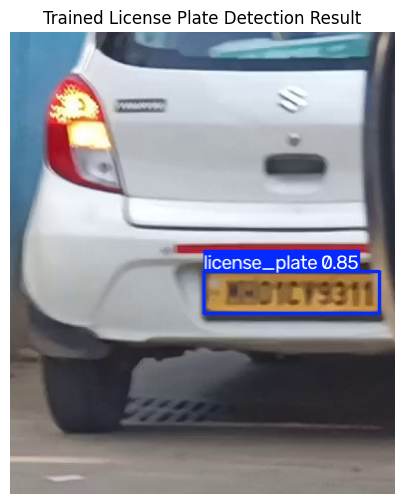

In [50]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

# Load the best trained model
best_model = YOLO(
    "/content/license_plate_project/license_plate_model/weights/best.pt"
)

# Select one validation image
val_images_path = "/content/license_plate_dataset/archive/images/val"
val_image_name = os.listdir(val_images_path)[0]
val_image_path = os.path.join(val_images_path, val_image_name)

print("Testing validation image:", val_image_name)

# Run license plate detection
results = best_model(val_image_path)

# Display result
annotated_image = results[0].plot()

plt.figure(figsize=(10, 6))
plt.imshow(annotated_image[:, :, ::-1])
plt.axis("off")
plt.title("Trained License Plate Detection Result")
plt.show()

## Step 17: Evaluate the Model on Multiple Validation Images

The trained YOLO model is tested on multiple validation images to observe its performance on different vehicles and license plates. Reviewing several examples helps identify successful detections as well as possible failure cases.

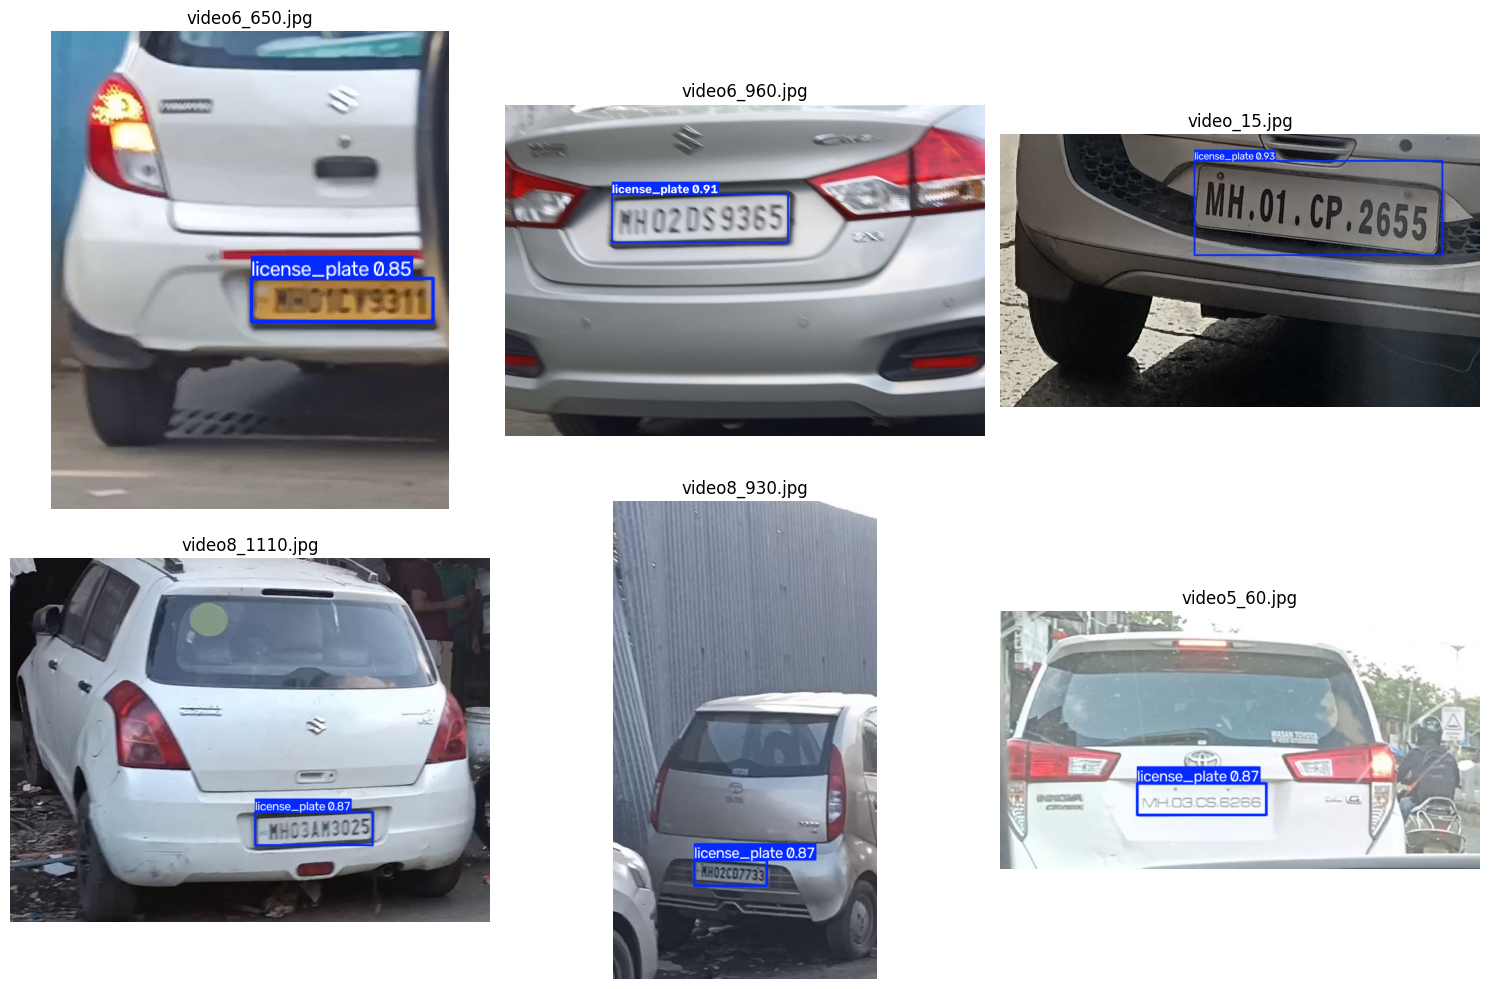

In [51]:
import os
import matplotlib.pyplot as plt

val_images_path = "/content/license_plate_dataset/archive/images/val"

# Select six validation images
sample_val_images = os.listdir(val_images_path)[:6]

plt.figure(figsize=(15, 10))

for i, image_name in enumerate(sample_val_images):
    image_path = os.path.join(val_images_path, image_name)

    # Run trained model
    results = best_model(image_path, verbose=False)

    # Get annotated result
    annotated_image = results[0].plot()

    plt.subplot(2, 3, i + 1)
    plt.imshow(annotated_image[:, :, ::-1])
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 18: Evaluate Model Performance

The trained license plate detection model is evaluated on the validation dataset using standard object detection metrics. Precision, recall, mAP50, and mAP50-95 are used to measure the model's detection performance.

In [52]:
metrics = best_model.val(
    data="/content/license_plate_dataset/archive/data.yaml"
)

print("\nModel Evaluation Results")
print("------------------------")
print("Precision:", round(metrics.box.mp, 4))
print("Recall:", round(metrics.box.mr, 4))
print("mAP50:", round(metrics.box.map50, 4))
print("mAP50-95:", round(metrics.box.map, 4))

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3238.0±1245.3 MB/s, size: 204.2 KB)
val: Scanning /content/license_plate_dataset/archive/labels/val.cache... 169 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 54.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.3it/s 4.7s
                   all        169        169      0.993      0.988      0.994       0.88
Speed: 3.6ms preprocess, 4.8ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to /content/runs/detect/val-2

Model Evaluation Results
------------------------
Precision: 0.9929
Recall: 0.9882
mAP50: 0.9941
mAP50-95: 0.8802


## Step 19: Review Success and Failure Cases

The trained model is tested on several validation images to examine both successful detections and challenging cases. Reviewing confidence scores and missed or incorrect detections helps identify the strengths and limitations of the license plate detection model.

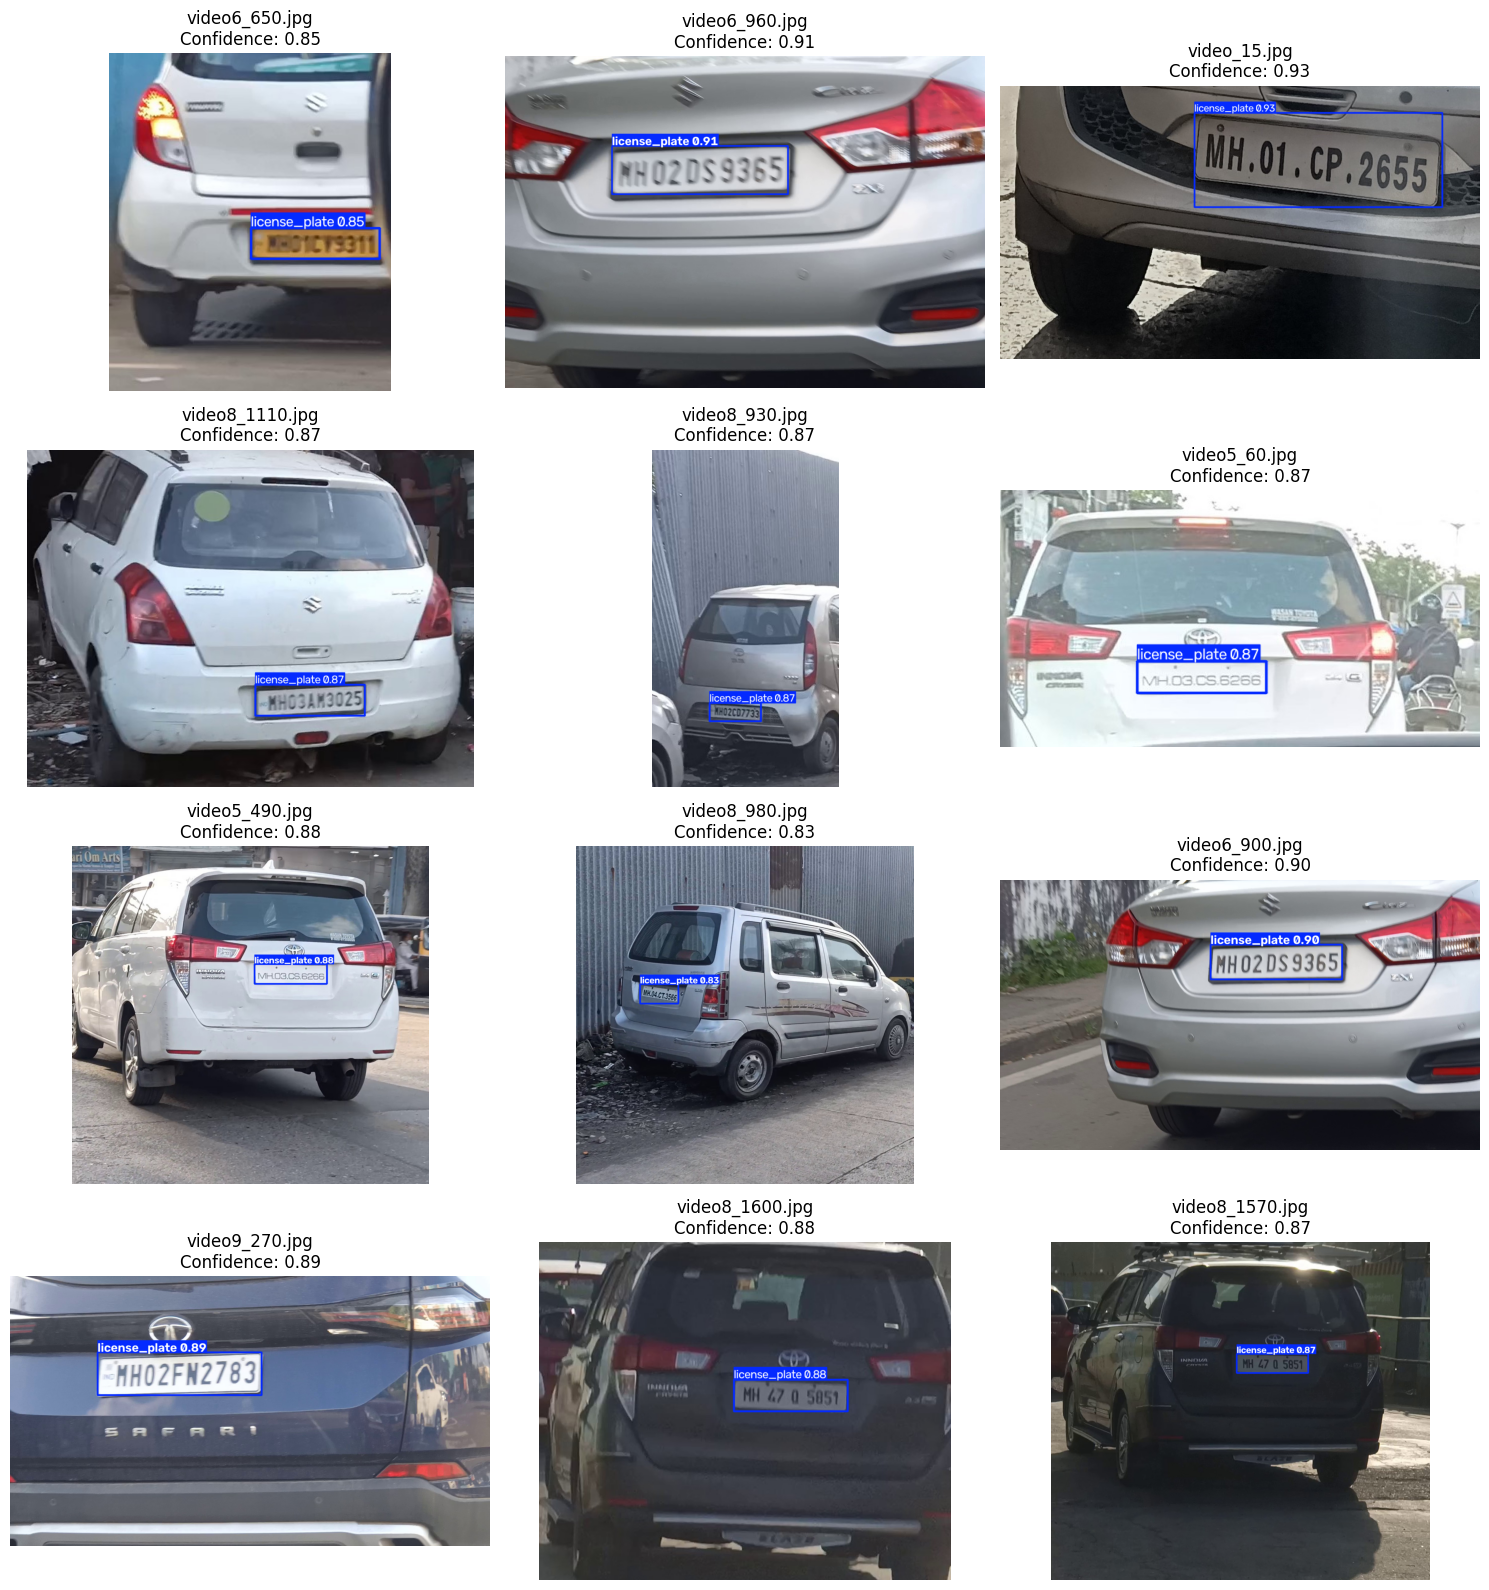

In [53]:
import os
import matplotlib.pyplot as plt

val_images_path = "/content/license_plate_dataset/archive/images/val"
test_images = os.listdir(val_images_path)[:12]

plt.figure(figsize=(15, 16))

for i, image_name in enumerate(test_images):
    image_path = os.path.join(val_images_path, image_name)

    results = best_model(image_path, verbose=False)
    annotated_image = results[0].plot()

    # Get highest confidence score
    if len(results[0].boxes) > 0:
        confidence = float(results[0].boxes.conf.max())
        title = f"{image_name}\nConfidence: {confidence:.2f}"
    else:
        title = f"{image_name}\nNo Detection"

    plt.subplot(4, 3, i + 1)
    plt.imshow(annotated_image[:, :, ::-1])
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 20: Save the Trained Model

The best trained YOLO model is copied to Google Drive for safe storage. This prevents the trained model from being lost if the Google Colab runtime disconnects or restarts.

In [54]:
import os
import shutil

source_model = "/content/license_plate_project/license_plate_model/weights/best.pt"

drive_folder = "/content/drive/MyDrive/License_Plate_Project"
os.makedirs(drive_folder, exist_ok=True)

destination_model = os.path.join(drive_folder, "best_license_plate_model.pt")

shutil.copy(source_model, destination_model)

print("Trained model saved successfully!")
print("Saved location:", destination_model)

Trained model saved successfully!
Saved location: /content/drive/MyDrive/License_Plate_Project/best_license_plate_model.pt


## Step 21: Save Training and Evaluation Results

The YOLO training results are copied to Google Drive for safe storage. These results include performance graphs, validation outputs, and other files that can be used to evaluate and present the model's performance.

In [55]:
import os
import shutil

source_results = "/content/license_plate_project/license_plate_model"
destination_results = "/content/drive/MyDrive/License_Plate_Project/training_results"

if os.path.exists(destination_results):
    shutil.rmtree(destination_results)

shutil.copytree(source_results, destination_results)

print("Training results saved successfully!")
print("Saved location:", destination_results)

Training results saved successfully!
Saved location: /content/drive/MyDrive/License_Plate_Project/training_results
